Загружаем две таблицы и соединяем их по индексу внутренним соединением. В файлах первый столбец — это номер строки, его в признаки не берём. Ноутбук запускаем из корня проекта, Excel-файлы должны лежать в `data/raw`. Папки для результатов создаём ниже.


In [1]:
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, KFold
from sklearn.pipeline import Pipeline
from sklearn.base import clone
from sklearn.preprocessing import MinMaxScaler
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.metrics import mean_absolute_error, r2_score
import joblib
from pathlib import Path

for papka in ["data/processed", "models", "figures"]:
    Path(papka).mkdir(parents=True, exist_ok=True)

df_bp = pd.read_excel("data/raw/X_bp.xlsx", index_col=0)
df_nup = pd.read_excel("data/raw/X_nup.xlsx", index_col=0)
df = df_bp.join(df_nup, how="inner")
print(df.shape)
df.head()


(1023, 13)


,Соотношение матрица-наполнитель,"Плотность, кг/м3","модуль упругости, ГПа","Количество отвердителя, м.%","Содержание эпоксидных групп,%_2","Температура вспышки, С_2","Поверхностная плотность, г/м2","Модуль упругости при растяжении, ГПа","Прочность при растяжении, МПа","Потребление смолы, г/м2","Угол нашивки, град",Шаг нашивки,Плотность нашивки
0,1.857143,2030.0,738.736842,30.00,22.267857,100.000000,210.0,70.0,3000.0,220.0,0,4.0,57.0
1,1.857143,2030.0,738.736842,50.00,23.750000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,60.0
2,1.857143,2030.0,738.736842,49.90,33.000000,284.615385,210.0,70.0,3000.0,220.0,0,4.0,70.0
3,1.857143,2030.0,738.736842,129.00,21.250000,300.000000,210.0,70.0,3000.0,220.0,0,5.0,47.0
4,2.771331,2030.0,753.000000,111.86,22.267857,284.615385,210.0,70.0,3000.0,220.0,0,5.0,57.0


Смотрим пропуски, среднее, медиану, минимум и максимум. Если среднее сильно отличается от медианы, в столбце есть значения, которые тянут его в сторону.

In [2]:
print(df.isna().sum())
print(df["Угол нашивки, град"].value_counts())
opisanie = df.agg(["mean", "median", "min", "max"]).T
opisanie.to_csv("models/opisanie.csv")
opisanie.round(3)


Соотношение матрица-наполнитель         0
Плотность, кг/м3                        0
модуль упругости, ГПа                   0
Количество отвердителя, м.%             0
Содержание эпоксидных групп,%_2         0
Температура вспышки, С_2                0
Поверхностная плотность, г/м2           0
Модуль упругости при растяжении, ГПа    0
Прочность при растяжении, МПа           0
Потребление смолы, г/м2                 0
Угол нашивки, град                      0
Шаг нашивки                             0
Плотность нашивки                       0
dtype: int64
Угол нашивки, град
0     520
90    503
Name: count, dtype: int64


,mean,median,min,max
Соотношение матрица-наполнитель,2.930,2.907,0.389,5.592
"Плотность, кг/м3",1975.735,1977.622,1731.765,2207.773
"модуль упругости, ГПа",739.923,739.664,2.437,1911.536
"Количество отвердителя, м.%",110.571,110.565,17.740,198.953
"Содержание эпоксидных групп,%_2",22.244,22.231,14.255,33.000
"Температура вспышки, С_2",285.882,285.897,100.000,413.273
"Поверхностная плотность, г/м2",482.732,451.864,0.604,1399.542
"Модуль упругости при растяжении, ГПа",73.329,73.269,64.054,82.682
"Прочность при растяжении, МПа",2466.923,2459.525,1036.857,3848.437
"Потребление смолы, г/м2",218.423,219.199,33.803,414.591


Гистограммы и ящики с усами показывают форму каждого столбца и точки, которые стоят далеко от основной массы.

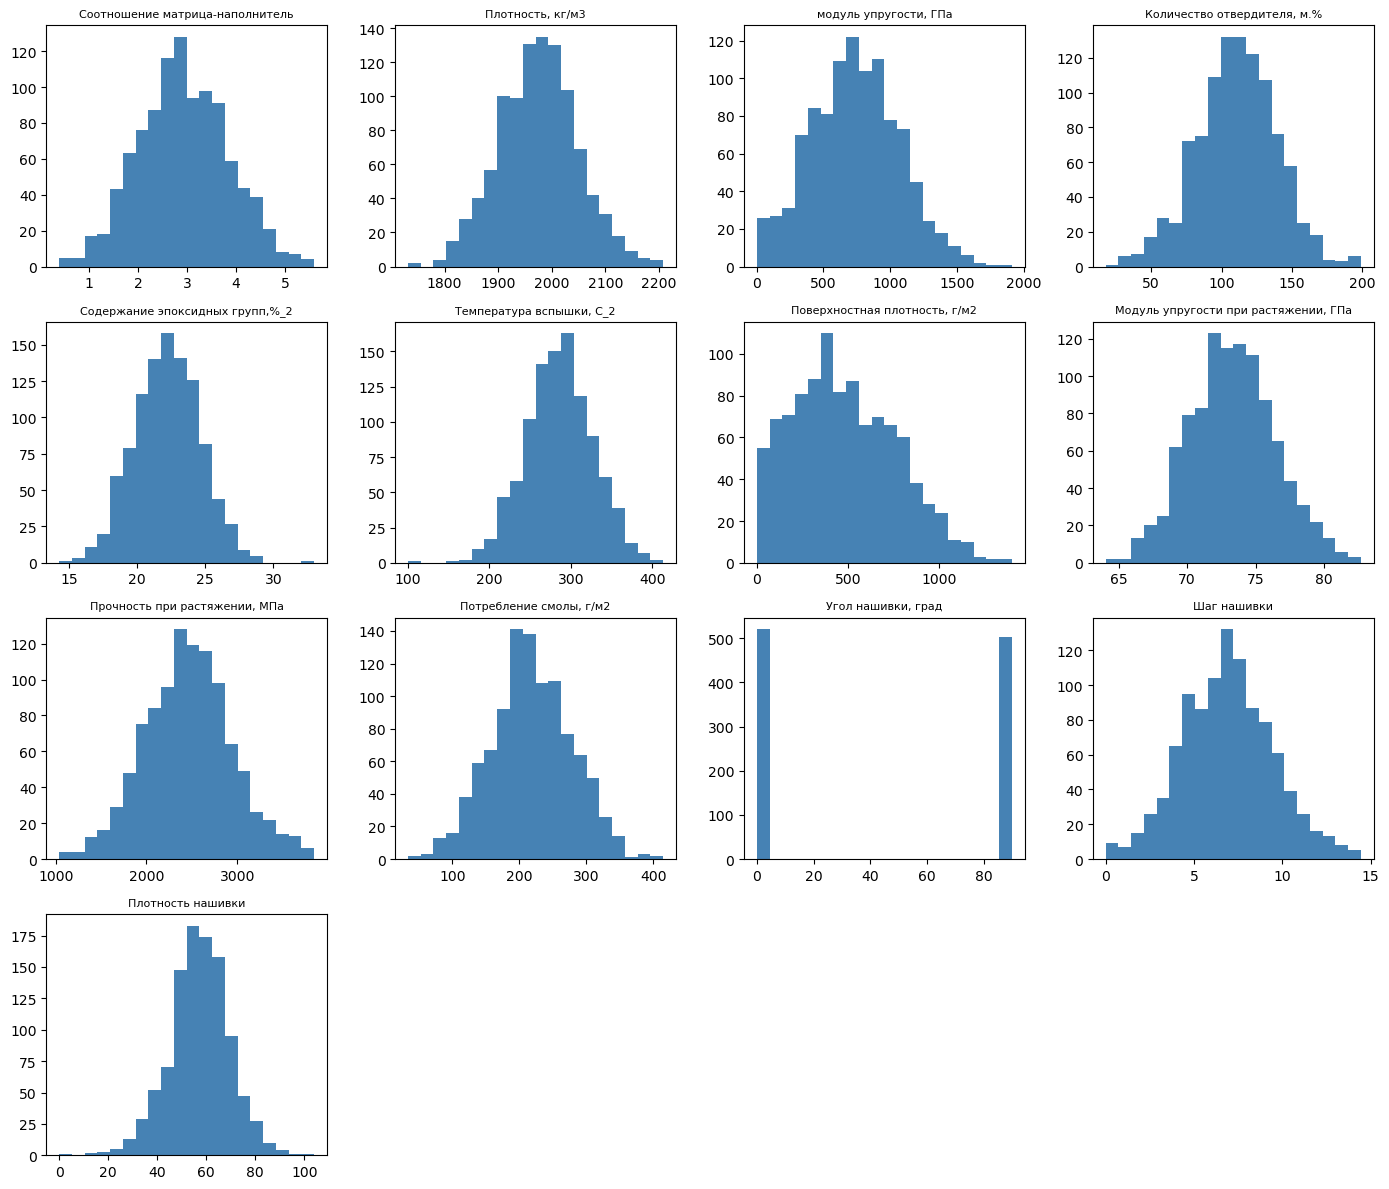

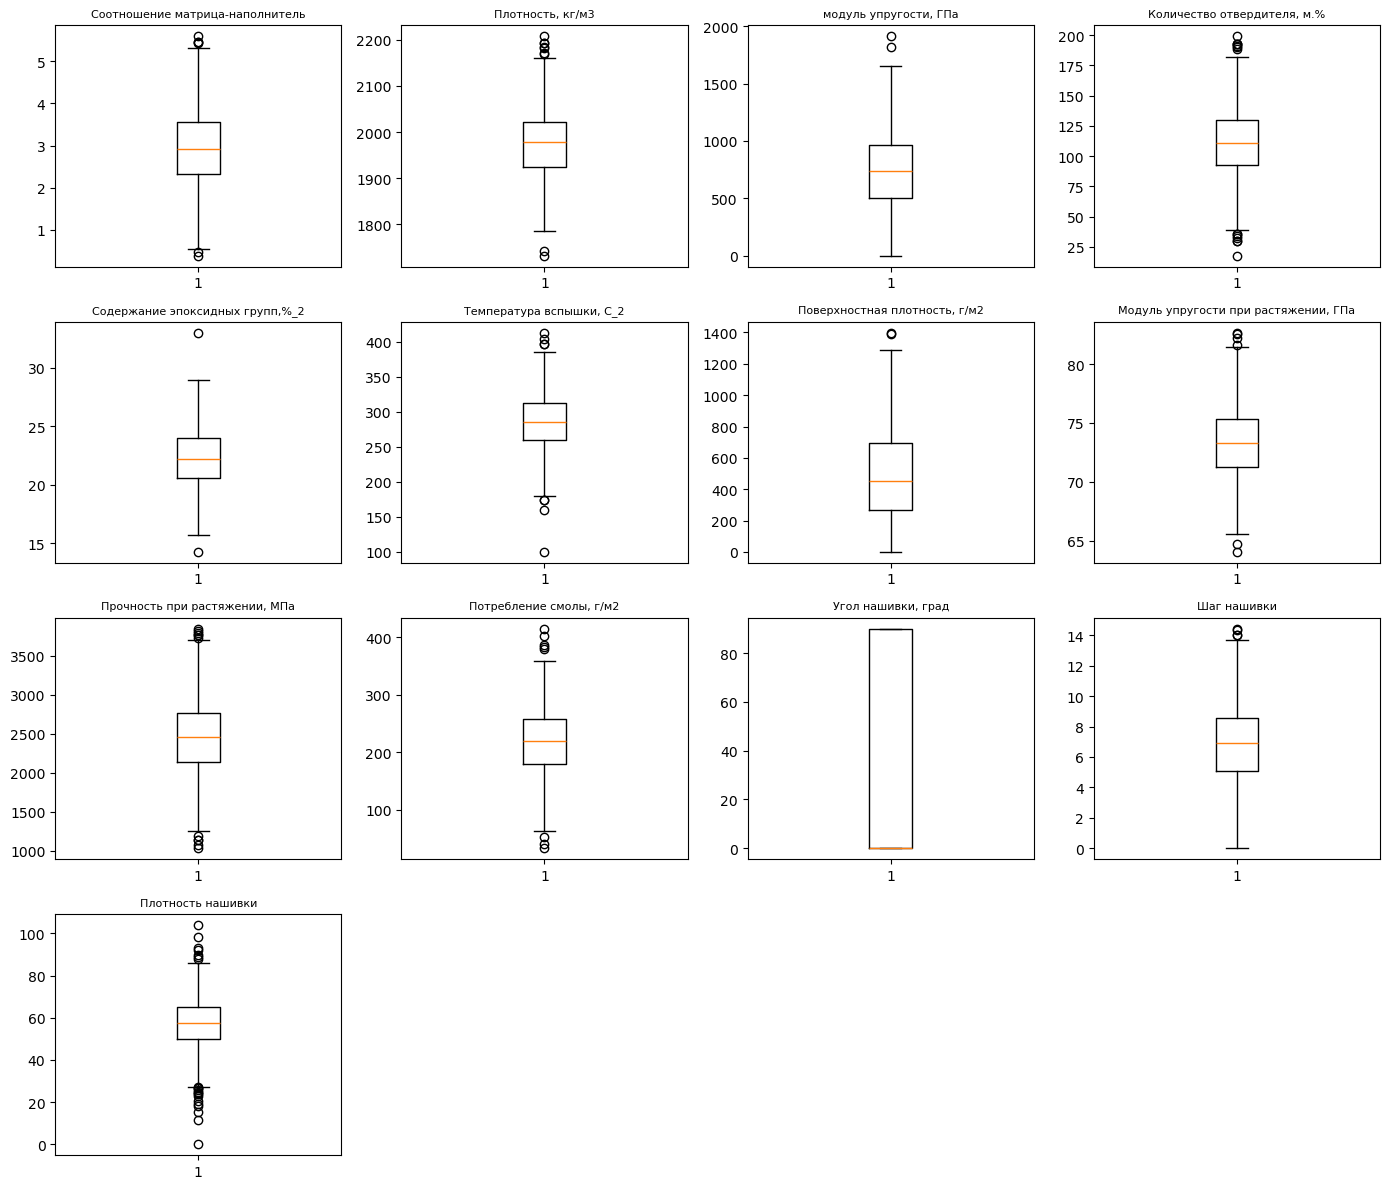

In [3]:
fig, axes = plt.subplots(4, 4, figsize=(14, 12))
axes = axes.ravel()
for i, col in enumerate(df.columns):
    axes[i].hist(df[col], bins=20, color="steelblue")
    axes[i].set_title(col, fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.tight_layout()
fig.savefig("figures/hist_ishodnye.png", dpi=120)
plt.show()

fig, axes = plt.subplots(4, 4, figsize=(14, 12))
axes = axes.ravel()
for i, col in enumerate(df.columns):
    axes[i].boxplot(df[col])
    axes[i].set_title(col, fontsize=8)
for j in range(i + 1, len(axes)):
    axes[j].axis("off")
fig.tight_layout()
fig.savefig("figures/box_do.png", dpi=120)
plt.show()


Попарные диаграммы и тепловая карта нужны, чтобы увидеть, есть ли связь между столбцами. На диаграмме оставлены пары без повтора в нижней половине.


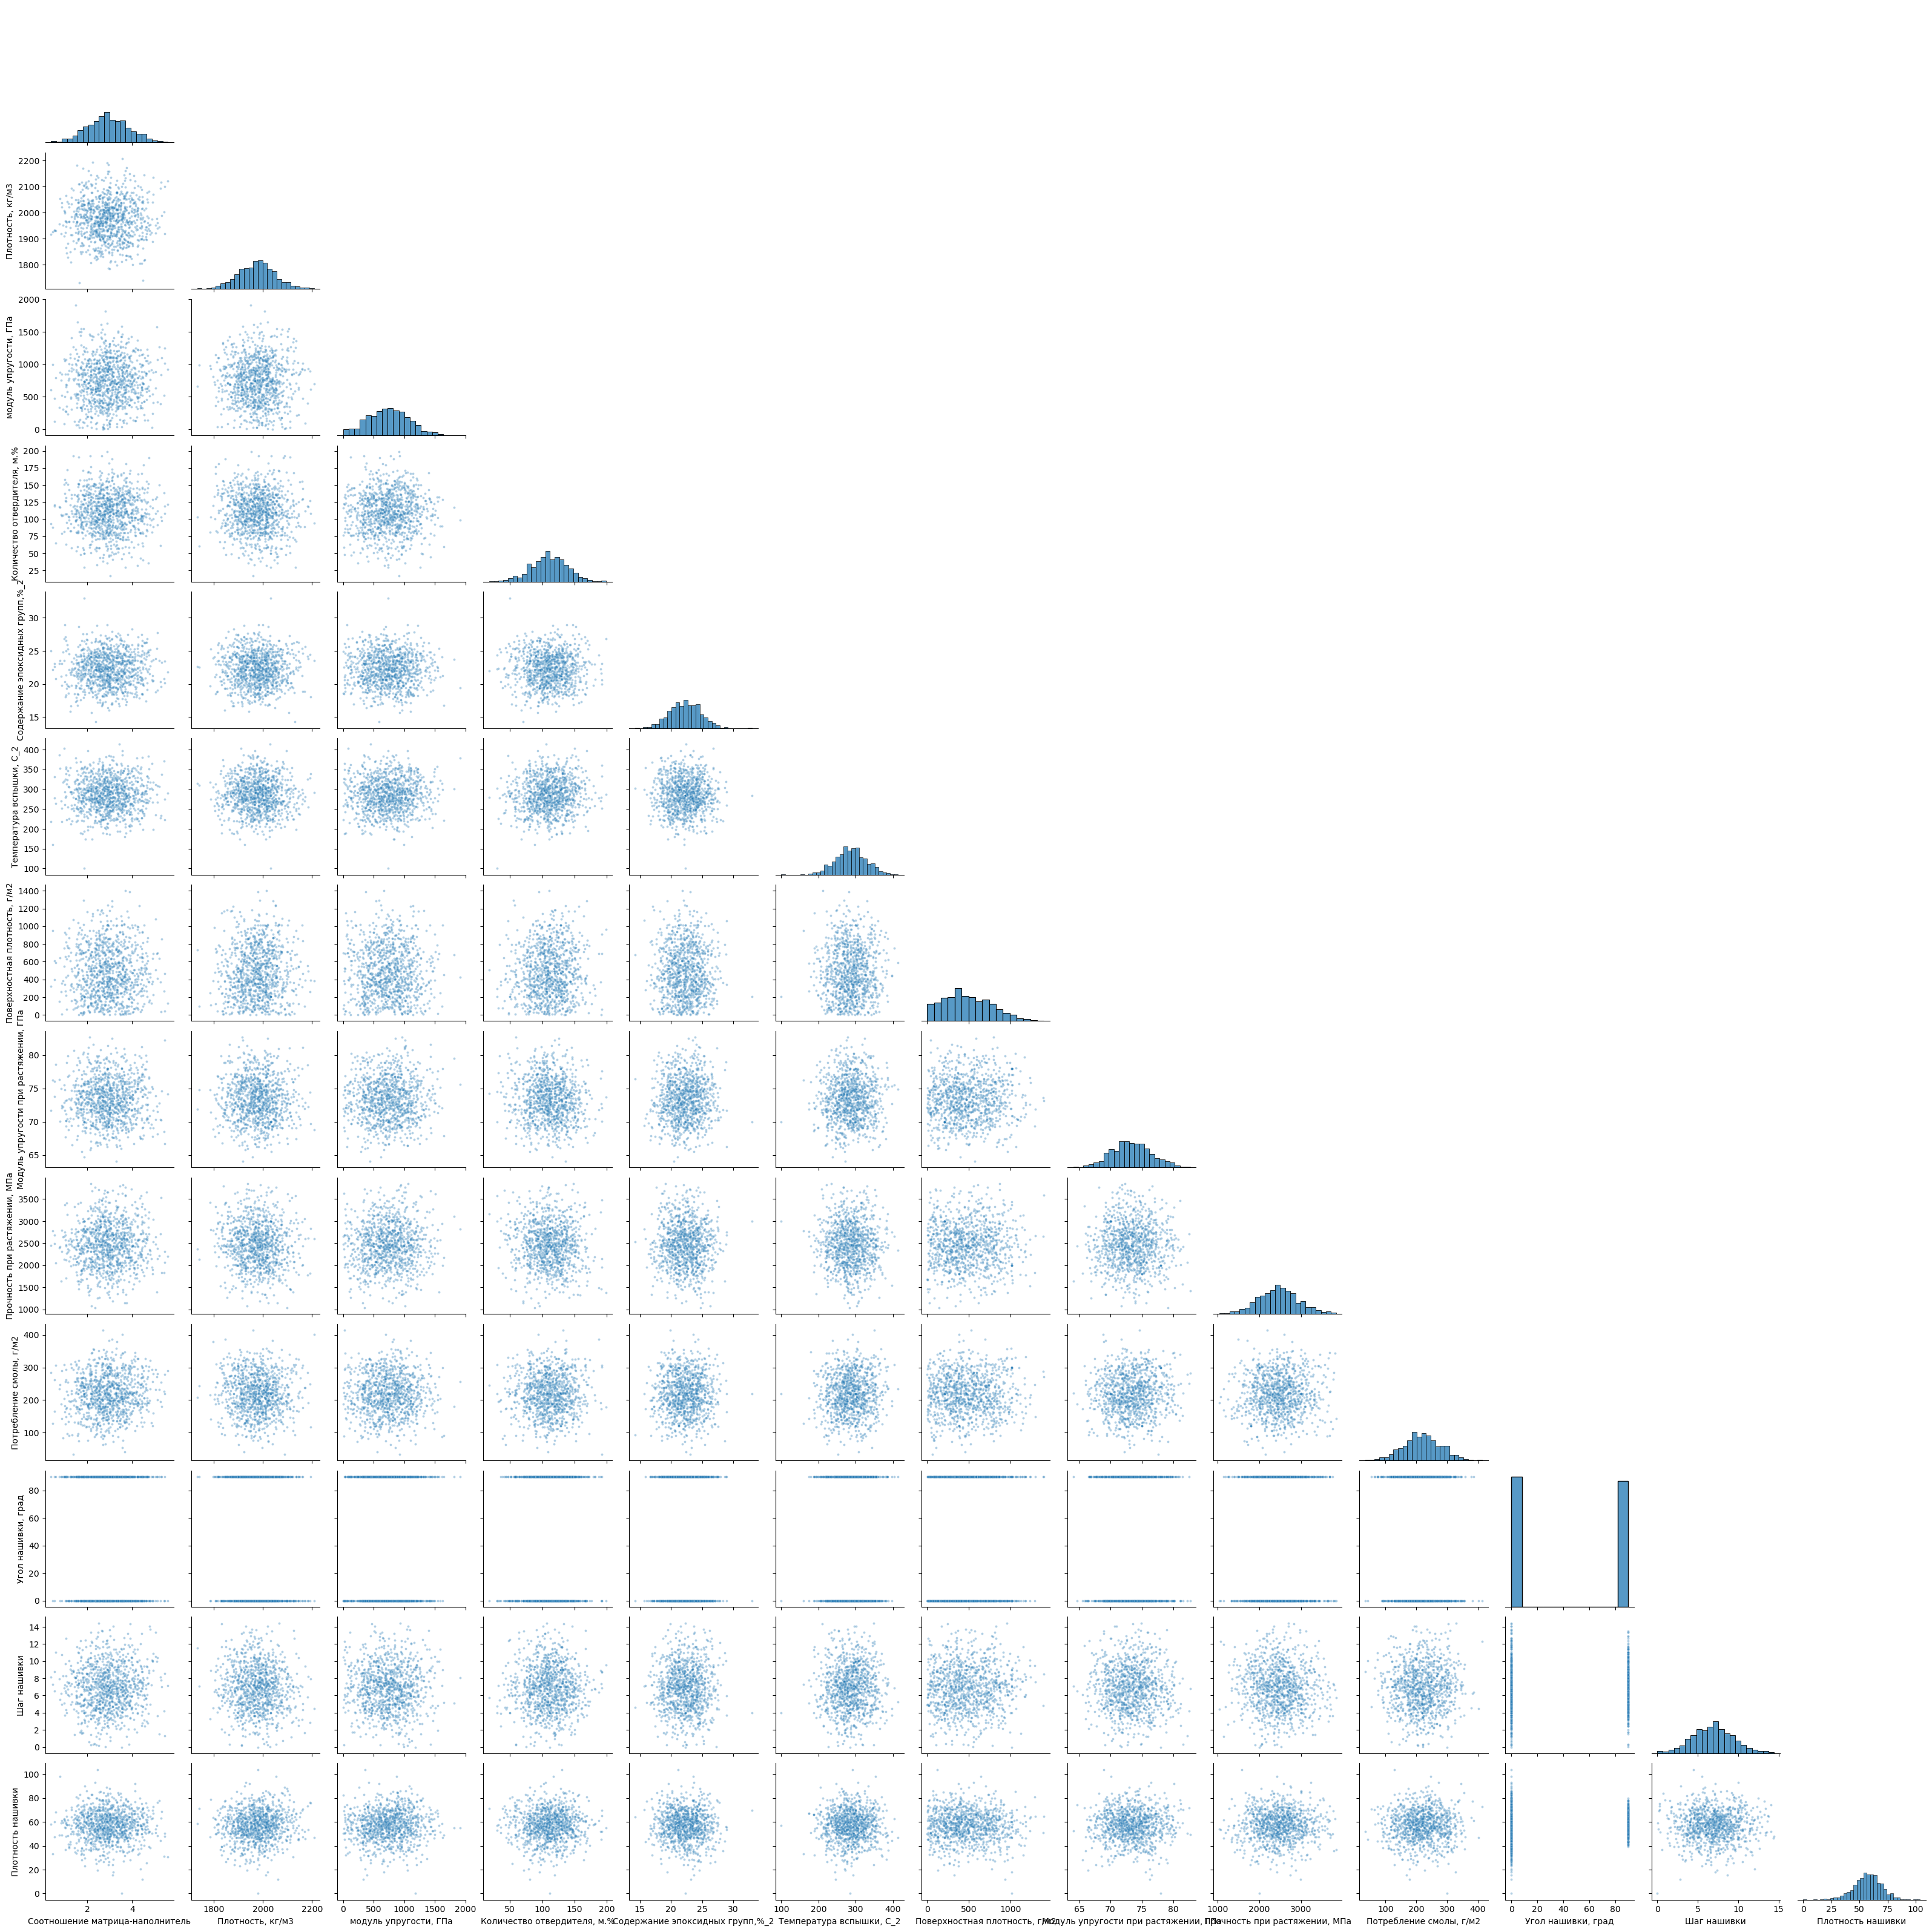

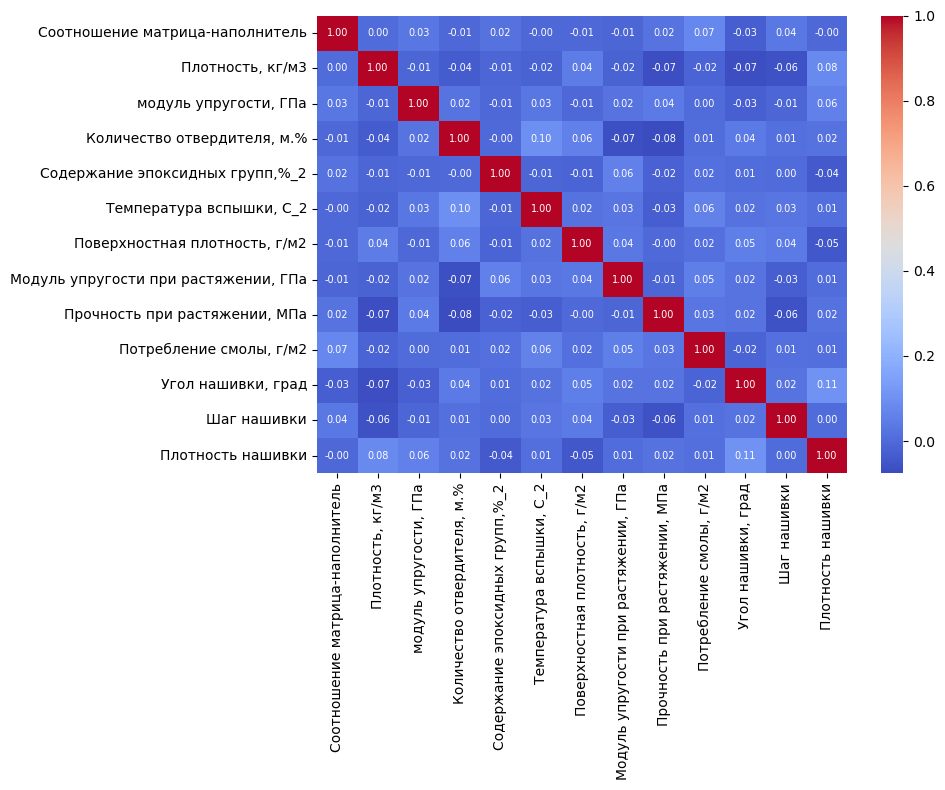

In [4]:
graf = sns.pairplot(df, corner=True, diag_kind="hist", plot_kws={"s": 8, "alpha": 0.35}, diag_kws={"color": "C0"})
graf.savefig("figures/scatter_pair.png", dpi=80)
plt.show()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm", ax=ax, annot_kws={"size": 7})
fig.tight_layout()
fig.savefig("figures/corr.png", dpi=120)
plt.show()


Сначала оставляем 30 процентов исходных данных на тест. Выбросом считаем значение за границей полутора межквартильных размахов. Для двух моделей свойств проверяем только входные признаки, обе цели в эту проверку не включаем. Тест не очищаем. В каждом из десяти блоков границы считаем только по его обучающим строкам, проверочные строки не удаляем.


In [5]:
train, test = train_test_split(df, test_size=0.3, random_state=42)
print("Обучение и тест:", len(train), len(test))

celi = [
    "Модуль упругости при растяжении, ГПа",
    "Прочность при растяжении, МПа",
]
priznaki = df.columns.drop(celi).tolist()


def bez_vybrosov(dannye):
    vybros = pd.Series(False, index=dannye.index)
    for col in dannye.columns:
        q1 = dannye[col].quantile(0.25)
        q3 = dannye[col].quantile(0.75)
        iqr = q3 - q1
        niz = q1 - 1.5 * iqr
        verh = q3 + 1.5 * iqr
        vybros = vybros | (dannye[col] < niz) | (dannye[col] > verh)
    return ~vybros


ostavit = bez_vybrosov(train[priznaki])
df_clean = train.loc[ostavit].copy()
print("Строк с выбросом в обучении:", int((~ostavit).sum()))
print("Останется в обучении:", len(df_clean))
df_clean.to_csv("data/processed/data_clean.csv", index=False)

# В GridSearchCV передаём десять пар индексов: обучение без выбросов и полный блок проверки.
bloki = []
for train_idx, val_idx in KFold(n_splits=10).split(train):
    blok = train.iloc[train_idx][priznaki]
    ostavit_blok = bez_vybrosov(blok).to_numpy()
    bloki.append((train_idx[ostavit_blok], val_idx))


Обучение и тест: 716 307
Строк с выбросом в обучении: 53
Останется в обучении: 663


Для сравнения распределений нормируем очищенную обучающую часть. Этот нормировщик нужен только для графиков и таблицы. В моделях нормирование будет внутри Pipeline и обучится отдельно в каждом блоке. Целевые значения при обучении моделей оставляем в исходных единицах.


In [6]:
scaler = MinMaxScaler()
train_s = pd.DataFrame(
    scaler.fit_transform(df_clean), columns=df_clean.columns, index=df_clean.index
)

do = df_clean.agg(["min", "max"]).T
do.columns = ["min_do", "max_do"]
posle = train_s.agg(["min", "max"]).T
posle.columns = ["min_posle", "max_posle"]
granicy = do.join(posle)
granicy.to_csv("models/granicy.csv")
granicy.round(3)


,min_do,max_do,min_posle,max_posle
Соотношение матрица-наполнитель,0.547,5.296,0.0,1.0
"Плотность, кг/м3",1784.482,2160.751,0.0,1.0
"модуль упругости, ГПа",2.437,1572.096,0.0,1.0
"Количество отвердителя, м.%",38.669,181.828,0.0,1.0
"Содержание эпоксидных групп,%_2",15.696,28.955,0.0,1.0
"Температура вспышки, С_2",179.374,386.068,0.0,1.0
"Поверхностная плотность, г/м2",0.604,1291.340,0.0,1.0
"Модуль упругости при растяжении, ГПа",64.696,82.682,0.0,1.0
"Прочность при растяжении, МПа",1036.857,3848.437,0.0,1.0
"Потребление смолы, г/м2",75.832,359.052,0.0,1.0


Сравниваем одни и те же строки до и после нормирования. Меняется масштаб, а состав выборки остаётся прежним.


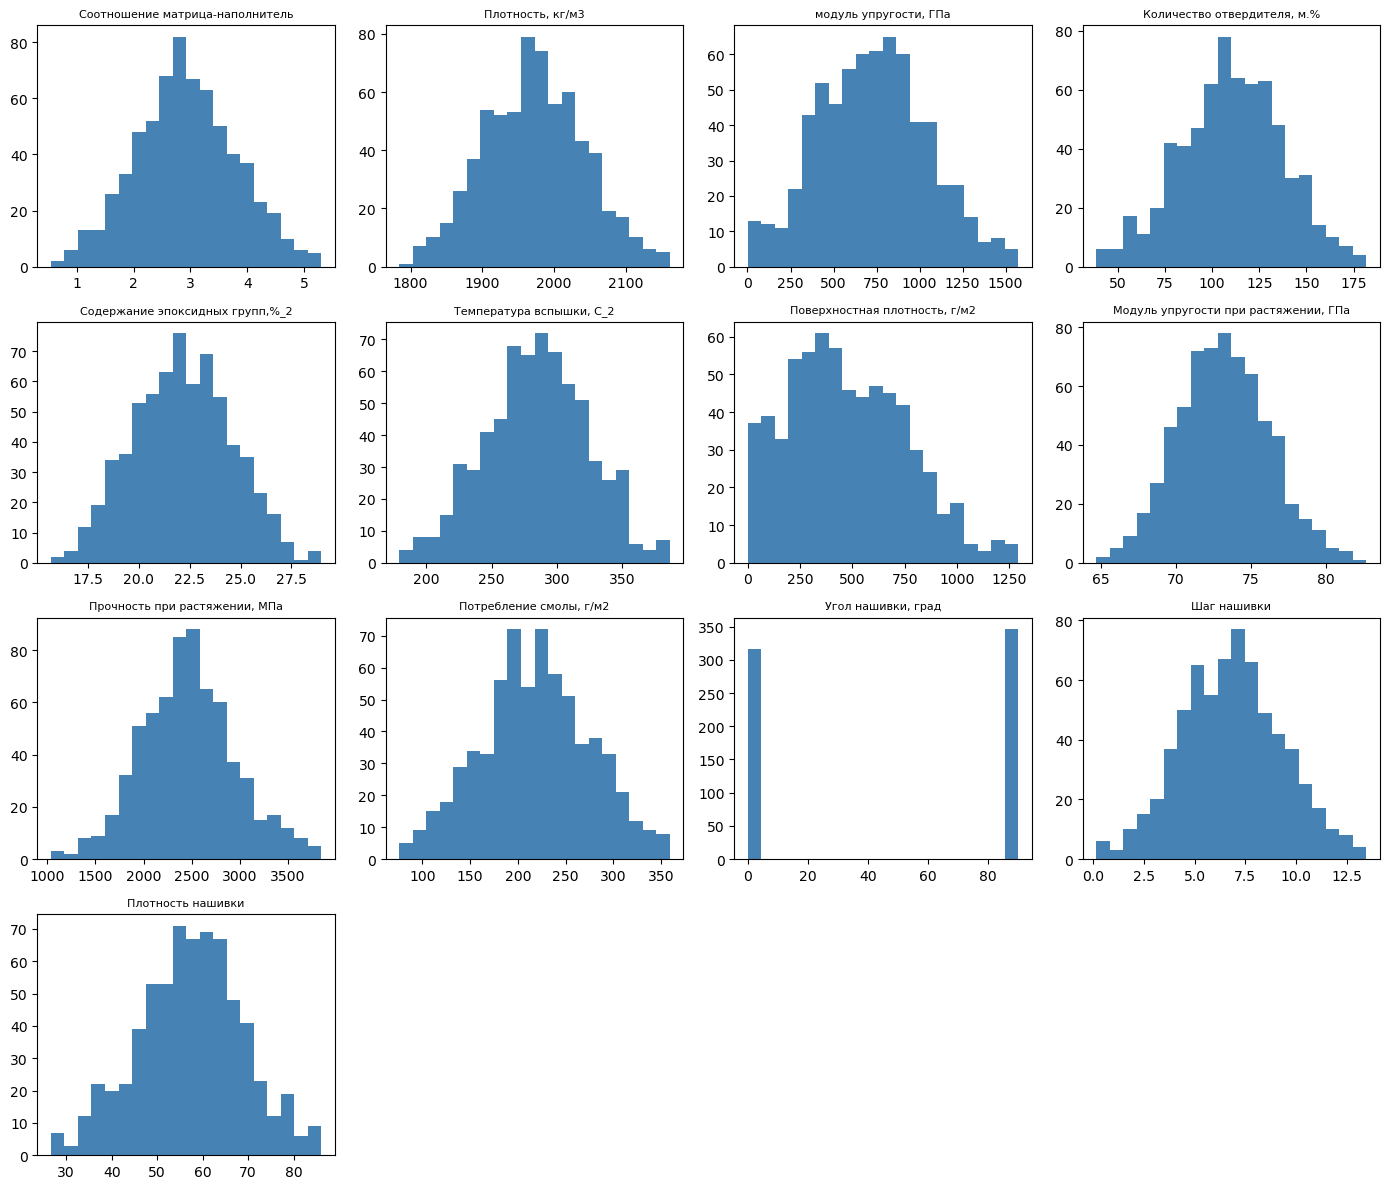

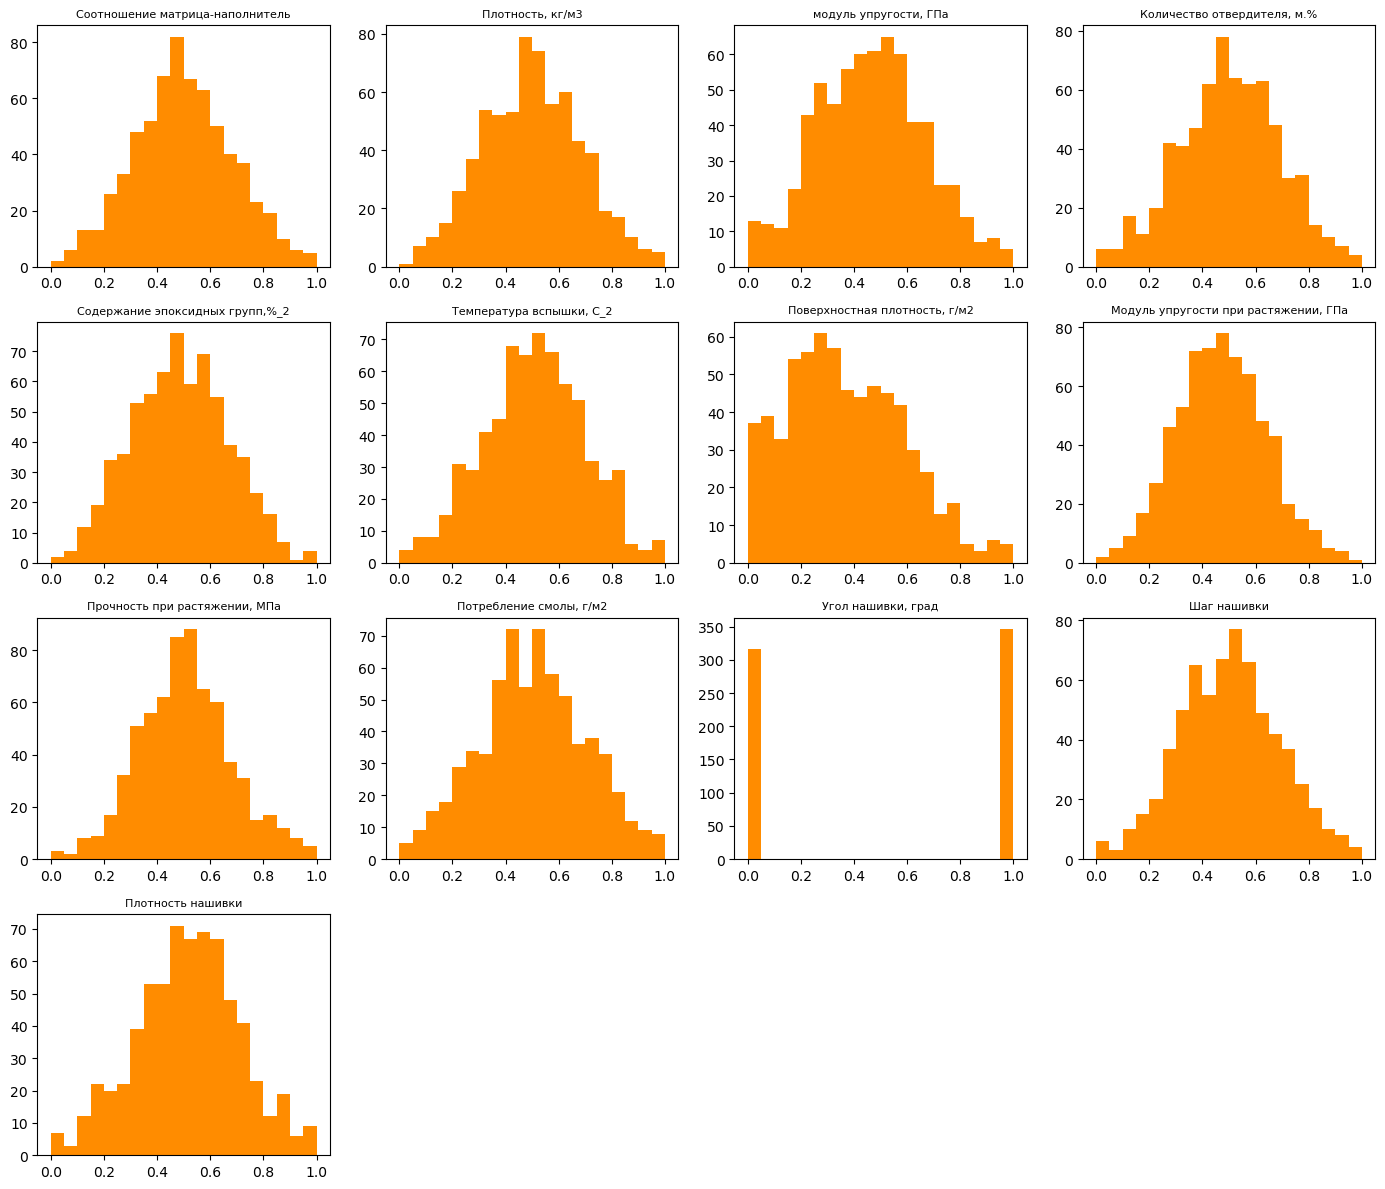

In [7]:
for dannye, imya, cvet in [
    (df_clean, "hist_do", "steelblue"),
    (train_s, "hist_posle", "darkorange"),
]:
    fig, axes = plt.subplots(4, 4, figsize=(14, 12))
    axes = axes.ravel()
    for i, col in enumerate(dannye.columns):
        axes[i].hist(dannye[col], bins=20, color=cvet)
        axes[i].set_title(col, fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].axis("off")
    fig.tight_layout()
    fig.savefig(f"figures/{imya}.png", dpi=120)
    plt.show()


Для модуля упругости при растяжении убираем из признаков обе конечные характеристики: при прогнозе они ещё неизвестны. Параметры трёх моделей выбираем по средней абсолютной ошибке на десяти блоках. После поиска отдельно обучаем каждую лучшую конфигурацию на очищенной обучающей части. Ошибку обучения считаем на этих строках, тестовую — на всём отложенном тесте.


In [8]:
cel = "Модуль упругости при растяжении, ГПа"
X_train = train[priznaki]
X_test = test[priznaki]
y_train = train[cel]
y_test = test[cel]

poisk_lin = GridSearchCV(
    Pipeline([("scaler", MinMaxScaler()), ("model", LinearRegression())]),
    {"model__fit_intercept": [True, False]},
    cv=bloki,
    refit=False,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
poisk_lin.fit(X_train, y_train)

poisk_les = GridSearchCV(
    Pipeline([("scaler", MinMaxScaler()), ("model", RandomForestRegressor(random_state=42))]),
    {"model__n_estimators": [100, 200], "model__max_depth": [5, 10, None]},
    cv=bloki,
    refit=False,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
poisk_les.fit(X_train, y_train)

poisk_bust = GridSearchCV(
    Pipeline([("scaler", MinMaxScaler()), ("model", GradientBoostingRegressor(random_state=42))]),
    {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [2, 3]},
    cv=bloki,
    refit=False,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
poisk_bust.fit(X_train, y_train)

stroki = []
modeli = {}
for nazvanie, poisk in [
    ("Линейная регрессия", poisk_lin),
    ("Случайный лес", poisk_les),
    ("Градиентный бустинг", poisk_bust),
]:
    model = clone(poisk.estimator).set_params(**poisk.best_params_)
    model.fit(X_train.loc[ostavit], y_train.loc[ostavit])
    modeli[nazvanie] = model
    pred_train = model.predict(X_train.loc[ostavit])
    pred_test = model.predict(X_test)
    stroki.append({
        "model": nazvanie,
        "params": str(poisk.best_params_),
        "mae_cv": -poisk.best_score_,
        "std_cv": poisk.cv_results_["std_test_score"][poisk.best_index_],
        "mae_train": mean_absolute_error(y_train.loc[ostavit], pred_train),
        "r2_train": r2_score(y_train.loc[ostavit], pred_train),
        "mae_test": mean_absolute_error(y_test, pred_test),
        "r2_test": r2_score(y_test, pred_test),
    })

itogi_modul = pd.DataFrame(stroki)
itogi_modul.to_csv("models/metrics_modul.csv", index=False)
itogi_modul.round(4)


,model,params,mae_cv,std_cv,mae_train,r2_train,mae_test,r2_test
0,Линейная регрессия,{'model__fit_intercept': True},2.5148,0.1781,2.4177,0.0216,2.5691,-0.0275
1,Случайный лес,"{'model__max_depth': 5, 'model__n_estimators':...",2.5157,0.1837,2.0843,0.2775,2.6155,-0.0615
2,Градиентный бустинг,"{'model__learning_rate': 0.05, 'model__max_dep...",2.5214,0.1894,2.2133,0.1752,2.5926,-0.0497


Берём модель с меньшей средней ошибкой перекрёстной проверки, а не теста. Смотрим, насколько прогноз на тесте близок к факту. Красная линия — это совпадение прогноза с фактом.


Линейная регрессия


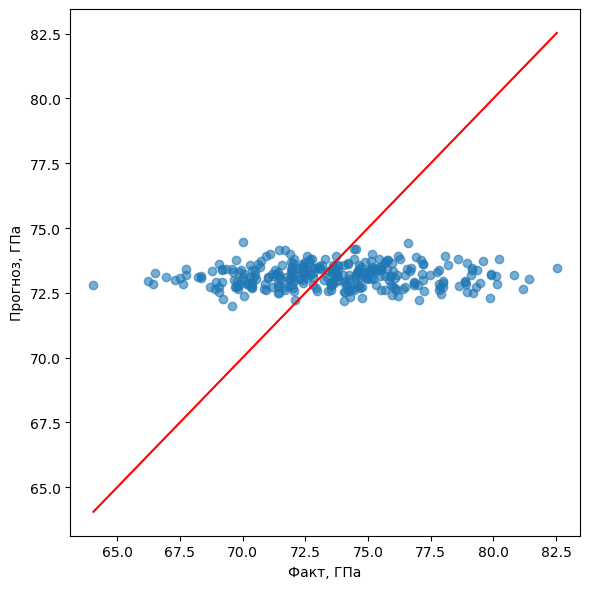

In [9]:
nomer = itogi_modul["mae_cv"].idxmin()
luchshaya_modul = itogi_modul.loc[nomer, "model"]
print(luchshaya_modul)

model_modul = modeli[luchshaya_modul]
pred_test = model_modul.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred_test, alpha=0.6)
niz = min(y_test.min(), pred_test.min())
verh = max(y_test.max(), pred_test.max())
ax.plot([niz, verh], [niz, verh], color="red")
ax.set_xlabel("Факт, ГПа")
ax.set_ylabel("Прогноз, ГПа")
fig.tight_layout()
fig.savefig("figures/fact_modul.png", dpi=120)
plt.show()


То же самое делаем для прочности при растяжении. Обе конечные характеристики снова убраны из признаков, параметры ищем отдельно.


In [10]:
cel = "Прочность при растяжении, МПа"
X_train = train[priznaki]
X_test = test[priznaki]
y_train = train[cel]
y_test = test[cel]

poisk_lin = GridSearchCV(
    Pipeline([("scaler", MinMaxScaler()), ("model", LinearRegression())]),
    {"model__fit_intercept": [True, False]},
    cv=bloki,
    refit=False,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
poisk_lin.fit(X_train, y_train)

poisk_les = GridSearchCV(
    Pipeline([("scaler", MinMaxScaler()), ("model", RandomForestRegressor(random_state=42))]),
    {"model__n_estimators": [100, 200], "model__max_depth": [5, 10, None]},
    cv=bloki,
    refit=False,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
poisk_les.fit(X_train, y_train)

poisk_bust = GridSearchCV(
    Pipeline([("scaler", MinMaxScaler()), ("model", GradientBoostingRegressor(random_state=42))]),
    {"model__n_estimators": [100, 200], "model__learning_rate": [0.05, 0.1], "model__max_depth": [2, 3]},
    cv=bloki,
    refit=False,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
poisk_bust.fit(X_train, y_train)

stroki = []
modeli = {}
for nazvanie, poisk in [
    ("Линейная регрессия", poisk_lin),
    ("Случайный лес", poisk_les),
    ("Градиентный бустинг", poisk_bust),
]:
    model = clone(poisk.estimator).set_params(**poisk.best_params_)
    model.fit(X_train.loc[ostavit], y_train.loc[ostavit])
    modeli[nazvanie] = model
    pred_train = model.predict(X_train.loc[ostavit])
    pred_test = model.predict(X_test)
    stroki.append({
        "model": nazvanie,
        "params": str(poisk.best_params_),
        "mae_cv": -poisk.best_score_,
        "std_cv": poisk.cv_results_["std_test_score"][poisk.best_index_],
        "mae_train": mean_absolute_error(y_train.loc[ostavit], pred_train),
        "r2_train": r2_score(y_train.loc[ostavit], pred_train),
        "mae_test": mean_absolute_error(y_test, pred_test),
        "r2_test": r2_score(y_test, pred_test),
    })

itogi_prochnost = pd.DataFrame(stroki)
itogi_prochnost.to_csv("models/metrics_prochnost.csv", index=False)
itogi_prochnost.round(4)


,model,params,mae_cv,std_cv,mae_train,r2_train,mae_test,r2_test
0,Линейная регрессия,{'model__fit_intercept': True},391.6767,26.4634,381.0056,0.0201,378.5736,0.0049
1,Случайный лес,"{'model__max_depth': 5, 'model__n_estimators':...",391.2497,25.3779,334.2059,0.2646,381.5052,0.0015
2,Градиентный бустинг,"{'model__learning_rate': 0.05, 'model__max_dep...",390.4841,24.5204,347.5814,0.1836,391.3091,-0.0223


Для прочности тоже оставляем модель с меньшей средней ошибкой перекрёстной проверки и строим график факта и прогноза на тесте.


Градиентный бустинг


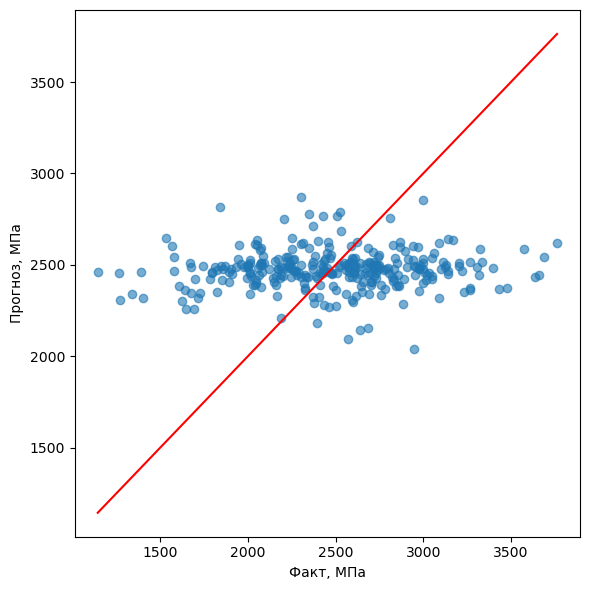

In [11]:
nomer = itogi_prochnost["mae_cv"].idxmin()
luchshaya_prochnost = itogi_prochnost.loc[nomer, "model"]
print(luchshaya_prochnost)

model_prochnost = modeli[luchshaya_prochnost]
pred_test = model_prochnost.predict(X_test)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_test, pred_test, alpha=0.6)
niz = min(y_test.min(), pred_test.min())
verh = max(y_test.max(), pred_test.max())
ax.plot([niz, verh], [niz, verh], color="red")
ax.set_xlabel("Факт, МПа")
ax.set_ylabel("Прогноз, МПа")
fig.tight_layout()
fig.savefig("figures/fact_prochnost.png", dpi=120)
plt.show()


Сеть оценивает соотношение матрица-наполнитель по остальным характеристикам. Здесь обе характеристики при растяжении считаем заданными входами обратной задачи. Это оценка по данным, а не доказанный оптимальный состав. Сеть полносвязная, с двумя скрытыми слоями и функцией ReLU; число нейронов выбираем из двух вариантов. Выбросы ищем только среди её входов и только в обучающих строках каждого блока.


In [12]:
cel = "Соотношение матрица-наполнитель"
X_train = train.drop(columns=[cel])
X_test = test.drop(columns=[cel])
y_train = train[cel]
y_test = test[cel]

ostavit_nn = bez_vybrosov(X_train)
print("Строк для обучения сети:", int(ostavit_nn.sum()))
bloki_nn = []
for train_idx, val_idx in KFold(n_splits=10).split(X_train):
    ostavit_blok = bez_vybrosov(X_train.iloc[train_idx]).to_numpy()
    bloki_nn.append((train_idx[ostavit_blok], val_idx))

poisk_nn = GridSearchCV(
    Pipeline([
        ("scaler", MinMaxScaler()),
        ("model", MLPRegressor(activation="relu", max_iter=1000, random_state=42, batch_size=32)),
    ]),
    {"model__hidden_layer_sizes": [(64, 32), (32, 16)]},
    cv=bloki_nn,
    refit=False,
    scoring="neg_mean_absolute_error",
    n_jobs=-1,
)
poisk_nn.fit(X_train, y_train)

model_nn = clone(poisk_nn.estimator).set_params(**poisk_nn.best_params_)
model_nn.fit(X_train.loc[ostavit_nn], y_train.loc[ostavit_nn])
pred_train = model_nn.predict(X_train.loc[ostavit_nn])
pred_test = model_nn.predict(X_test)
itogi_nn = pd.DataFrame([{
    "params": str(poisk_nn.best_params_),
    "mae_cv": -poisk_nn.best_score_,
    "std_cv": poisk_nn.cv_results_["std_test_score"][poisk_nn.best_index_],
    "mae_train": mean_absolute_error(y_train.loc[ostavit_nn], pred_train),
    "r2_train": r2_score(y_train.loc[ostavit_nn], pred_train),
    "mae_test": mean_absolute_error(y_test, pred_test),
    "r2_test": r2_score(y_test, pred_test),
}])
itogi_nn.to_csv("models/metrics_nn.csv", index=False)
print(model_nn.named_steps["model"].n_iter_)
itogi_nn.round(4)


Строк для обучения сети: 655
141


,params,mae_cv,std_cv,mae_train,r2_train,mae_test,r2_test
0,"{'model__hidden_layer_sizes': (32, 16)}",0.7603,0.054,0.6872,0.0642,0.7748,-0.0403


,params,mae_cv,std_cv,mae_train,r2_train,mae_test,r2_test
0,"{'model__hidden_layer_sizes': (32, 16)}",0.7603,0.054,0.6872,0.0642,0.7748,-0.0403


Сравниваем выбранные модели с прогнозом по среднему и медиане тех строк, на которых они обучались. Если ошибки близки, проверенная модель не показала убедительного преимущества над простым прогнозом. Это не доказывает, что в данных вообще нет зависимостей.


In [13]:
for cel_sr, model_sr, ostavit_sr in [
    ("Модуль упругости при растяжении, ГПа", model_modul, ostavit),
    ("Прочность при растяжении, МПа", model_prochnost, ostavit),
    ("Соотношение матрица-наполнитель", model_nn, ostavit_nn),
]:
    X_test_sr = test[model_sr.feature_names_in_]
    y_test_sr = test[cel_sr]
    y_train_sr = train.loc[ostavit_sr, cel_sr]
    pred_model = model_sr.predict(X_test_sr)
    pred_mean = [y_train_sr.mean()] * len(y_test_sr)
    pred_median = [y_train_sr.median()] * len(y_test_sr)
    print(cel_sr)
    print("модель", round(mean_absolute_error(y_test_sr, pred_model), 3))
    print("среднее", round(mean_absolute_error(y_test_sr, pred_mean), 3))
    print("медиана", round(mean_absolute_error(y_test_sr, pred_median), 3))


Модуль упругости при растяжении, ГПа
модель 2.569
среднее 2.56
медиана 2.573
Прочность при растяжении, МПа
модель 391.309
среднее 378.946
медиана 379.254
Соотношение матрица-наполнитель
модель 0.775
среднее 0.752
медиана 0.752


Сохраняем выбранные модели модуля упругости и прочности вместе с их нормировщиками внутри Pipeline. Приложение передаёт в predict исходные 11 признаков, отдельно нормировать их не нужно. Порядок столбцов есть в model.feature_names_in_. Медианы сохраняем только для входных признаков. Сеть остаётся в ноутбуке.


In [14]:
# в приложение уходят только две модели свойств, сеть остаётся в ноутбуке
joblib.dump(model_modul, "models/model_modul.joblib")
joblib.dump(model_prochnost, "models/model_prochnost.joblib")
joblib.dump(df_clean[priznaki].median(), "models/medians.joblib")
print(luchshaya_modul)
print(luchshaya_prochnost)


Линейная регрессия
Градиентный бустинг
